In [1]:
# First physical cell: standard library only, before numerical import or output.
from pathlib import Path
import hashlib, json
BASE = Path.cwd()
EXPECTED = {'data/observations.csv': '2ddeddcd35016ea1d8450f89bfd8a4ca4c2533b4448b1238db127fe68f8a38d6', 'data/model_spec.json': 'c78f52d40006d082b1ad9e20daa0622c94705d28e9164347bf6e09348b834861', 'data_integrity.json': '1bdfdf61631a2afa5476679c4c46f1cb65471ba0ca09e35862ae5ff6bae93261', 'experiment.py': '9cadbbc45169c17a5a07e52147f0f6ad39e86eb4370f46a05855ce40b08ef237', 'audit.py': '62702112f4321b6131dc6252686af4bae7f538164412ae384391b890631abd06', 'plots.py': '7d00a6342d8e970aa3c89fbfcd220a3d6d6c7c5ea4a5b3fc473b6f6445525c7f', 'requirements.txt': 'ed69e3c545b2f877637b883acdbb36124381dfc2605b2284e8a6a6b125464d5e', 'environment.yml': '40e0dbf07693df6becaf8aa67e5a10e58880d0a308a7501497ec32126c161179'}
for relative, wanted in EXPECTED.items():
    if hashlib.sha256((BASE / relative).read_bytes()).hexdigest() != wanted:
        raise ValueError('Teaching contract changed: ' + relative)
print('All eight teaching contracts verified before numerical work.')

All eight teaching contracts verified before numerical work.


# 第043讲 多分类与信息论损失

先阅读lecture.pdf与lab.pdf，再运行。八行是机制例；没有现实泛化或校准结论。下面将真正重新计算数值与图，不读取缓存报告。

Data: [('M1', [-1.0], 0), ('M2', [-1.0], 0), ('M3', [-1.0], 1), ('M4', [-1.0], 2), ('M5', [1.0], 0), ('M6', [1.0], 1), ('M7', [1.0], 2), ('M8', [1.0], 2)]
Configuration: {'kind': 'multiclass_information_v1', 'class_names': ['甲', '乙', '丙'], 'initial_theta': [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], 'learning_rate': 0.6, 'max_updates': 600, 'gradient_tolerance': 1e-10, 'fd_steps': [0.01, 0.001, 0.0001, 1e-05, 1e-06], 'shift_constants': [-1000.0, -7.0, 0.0, 11.0, 1000.0], 'extreme_logits': [[0.0, -40.0, -40.0], [1000.0, 0.0, -1000.0], [-1000.0, -1000.0, -1000.0]], 'information_q': [0.5, 0.3, 0.2], 'information_p': [0.7, 0.2, 0.1]}


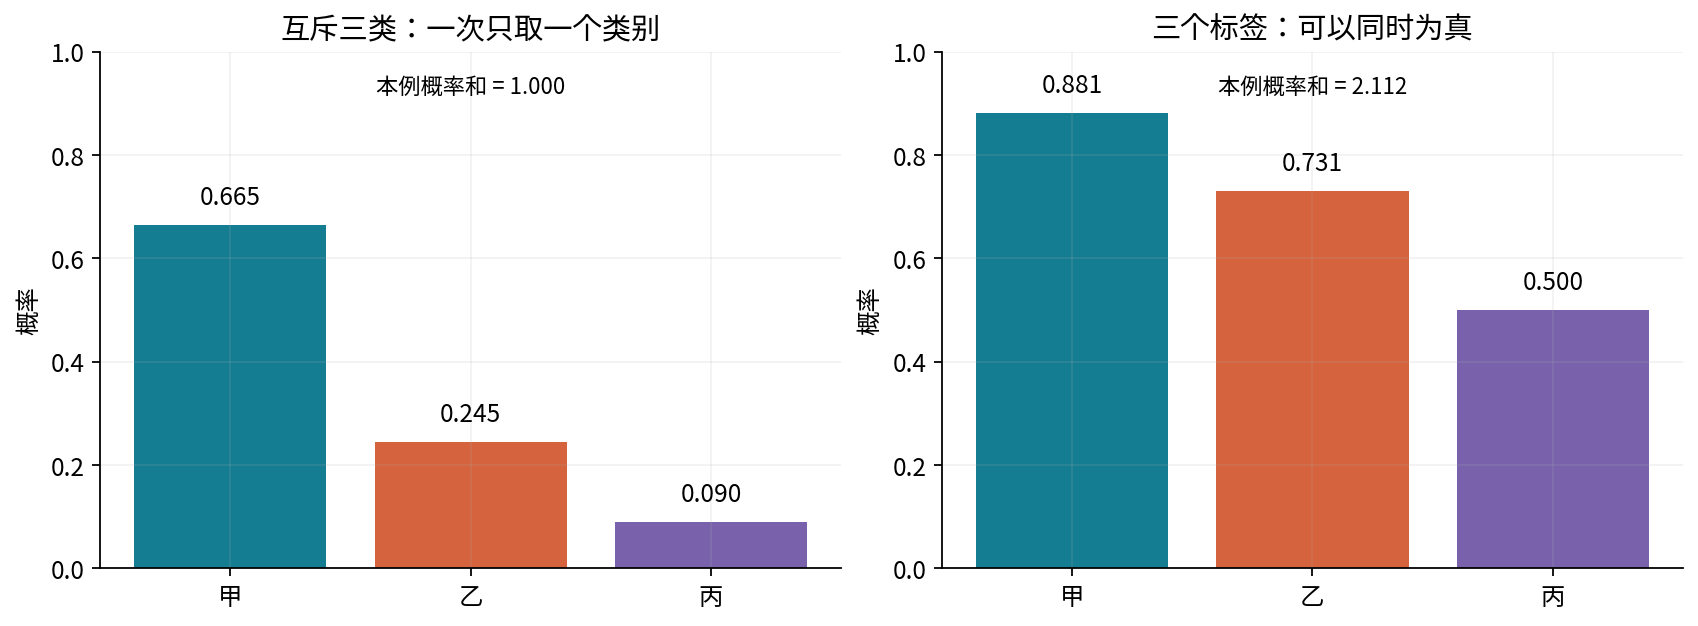

In [2]:
import os, io
os.environ.setdefault('MPLCONFIGDIR', str(BASE / 'outputs/mpl-cache'))
import numpy as np
import experiment as e
import plots
import matplotlib.pyplot as plt
from IPython.display import display, Image
X, y, ids, cfg = e.load_inputs()
report = e.main_report(X, y, ids, cfg)
def show(number):
    fig = plots.make_figure(number, report)
    stream = io.BytesIO()
    fig.savefig(stream, format='png', dpi=160, bbox_inches='tight')
    display(Image(data=stream.getvalue(), format='png'))
    plt.close(fig)
print('Data:', list(zip(ids, X.tolist(), y.tolist())))
print('Configuration:', cfg)
show(1)

## 三类共同归一化
预测得分(log2,0,log3)的概率与真实类乙的损失，再核对轴和平移。

Probabilities: [[0.33333333 0.16666667 0.5       ]] sum: [1.]
True class 1 loss: 1.791759469228055
Wrong axis=None row sums: [0.5 0.5]
Correct axis=1 row sums: [1. 1.]
{'shift': -1000.0, 'probability_max_error': 3.247402347028583e-15, 'log_probability_max_error': 1.887379141862766e-14}
{'shift': -7.0, 'probability_max_error': 8.326672684688674e-17, 'log_probability_max_error': 4.440892098500626e-16}
{'shift': 0.0, 'probability_max_error': 0.0, 'log_probability_max_error': 0.0}
{'shift': 11.0, 'probability_max_error': 1.6653345369377348e-16, 'log_probability_max_error': 4.440892098500626e-16}
{'shift': 1000.0, 'probability_max_error': 3.247402347028583e-15, 'log_probability_max_error': 1.887379141862766e-14}


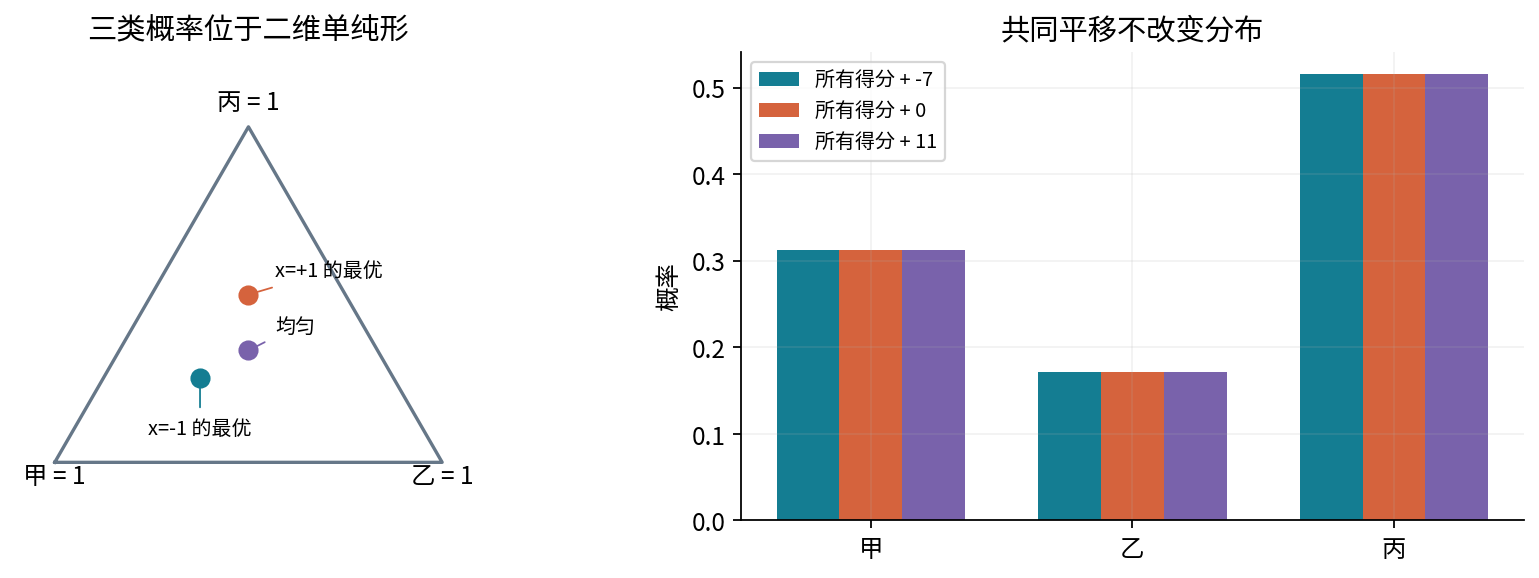

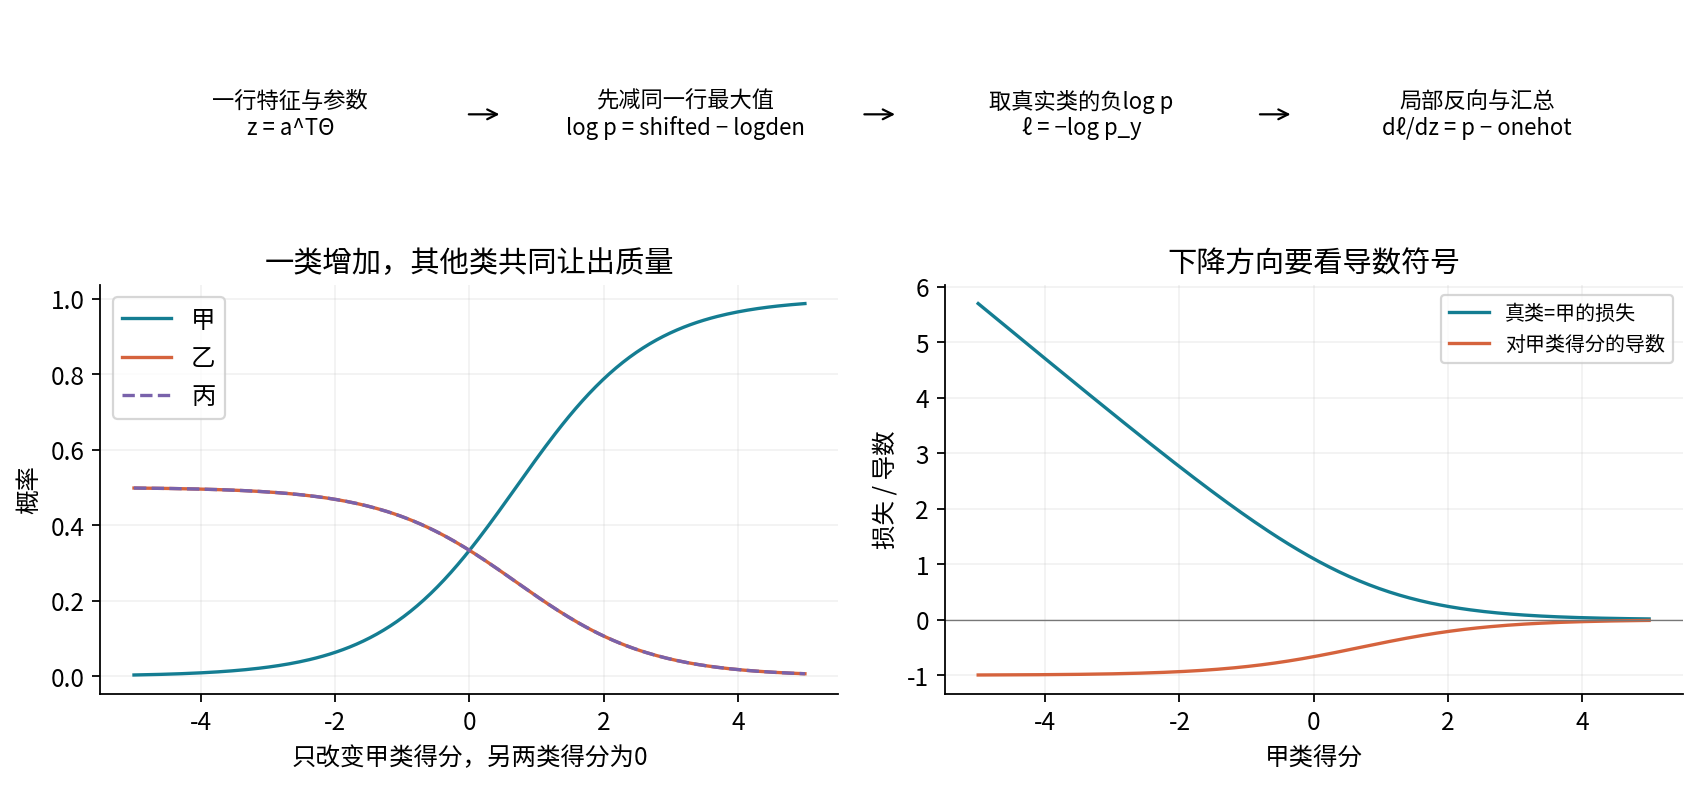

In [3]:
z = np.array([[np.log(2), 0., np.log(3)]])
p, logp = e.stable_softmax(z)
print('Probabilities:', p, 'sum:', p.sum(axis=1))
print('True class 1 loss:', -logp[0, 1])
from scipy.special import softmax
batch = np.array([[2., 1., 0.], [0., 1., 2.]])
print('Wrong axis=None row sums:', softmax(batch).sum(axis=1))
print('Correct axis=1 row sums:', softmax(batch, axis=1).sum(axis=1))
for item in report['diagnostics']['common_shifts']:
    print(item)
show(2)
show(3)

## 独立手动推进两次同步更新
所有行先用同一个旧参数，再将平均梯度一次提交。第三个状态是第二次更新后的新前向。

In [4]:
theta = np.array(cfg['initial_theta'])
hand = []
for k in range(3):
    state = e.row_ledger(X, y, theta)
    hand.append(state)
    print('STATE', k, 'Theta', state['theta'], 'F', state['objective'], 'G', state['gradient'])
    if k < 2:
        theta = theta - cfg['learning_rate'] * np.array(state['gradient'])
if e.canonical_bytes(hand) != e.canonical_bytes(report['hand_states']):
    raise RuntimeError('Manual staged calculation does not match fit states')

STATE 0 Theta [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]] F 1.0986122886681098 G [[-0.041666666666666706, 0.08333333333333333, -0.04166666666666666], [0.125, 0.0, -0.125]]
STATE 1 Theta [[0.025000000000000022, -0.049999999999999996, 0.024999999999999994], [-0.075, 0.0, 0.075]] F 1.0761523157586579 G [[-0.03313605698967949, 0.06627211397935905, -0.03313605698967953], [0.09940817096903856, 0.0, -0.09940817096903859]]
STATE 2 Theta [[0.04488163419380771, -0.08976326838761542, 0.04488163419380771], [-0.13464490258142314, 0.0, 0.13464490258142314]] F 1.0620115376133341 G [[-0.026101479117394202, 0.052202958234788405, -0.026101479117394202], [0.07830443735218261, 0.0, -0.07830443735218261]]



STATE 0 FULL EIGHT-ROW CHAIN
M1 {"design_row": [1.0, -1.0], "gradient_contribution": [[-0.08333333333333333, 0.041666666666666664, 0.041666666666666664], [0.08333333333333333, -0.041666666666666664, -0.041666666666666664]], "index": 1, "local_dloss_dp": [-3.0, 0.0, 0.0], "local_softmax_jacobian": [[0.2222222222222222, -0.1111111111111111, -0.1111111111111111], [-0.1111111111111111, 0.2222222222222222, -0.1111111111111111], [-0.1111111111111111, -0.1111111111111111, 0.2222222222222222]], "log_probabilities": [-1.0986122886681098, -1.0986122886681098, -1.0986122886681098], "logits": [0.0, 0.0, 0.0], "loss": 1.0986122886681098, "mean_loss_contribution": 0.13732653608351372, "probabilities": [0.3333333333333333, 0.3333333333333333, 0.3333333333333333], "probability_underflow": false, "stable_dloss_dz": [-0.6666666666666666, 0.3333333333333333, 0.3333333333333333], "x": [-1.0], "y": 0}
M2 {"design_row": [1.0, -1.0], "gradient_contribution": [[-0.08333333333333333, 0.041666666666666664, 0.0

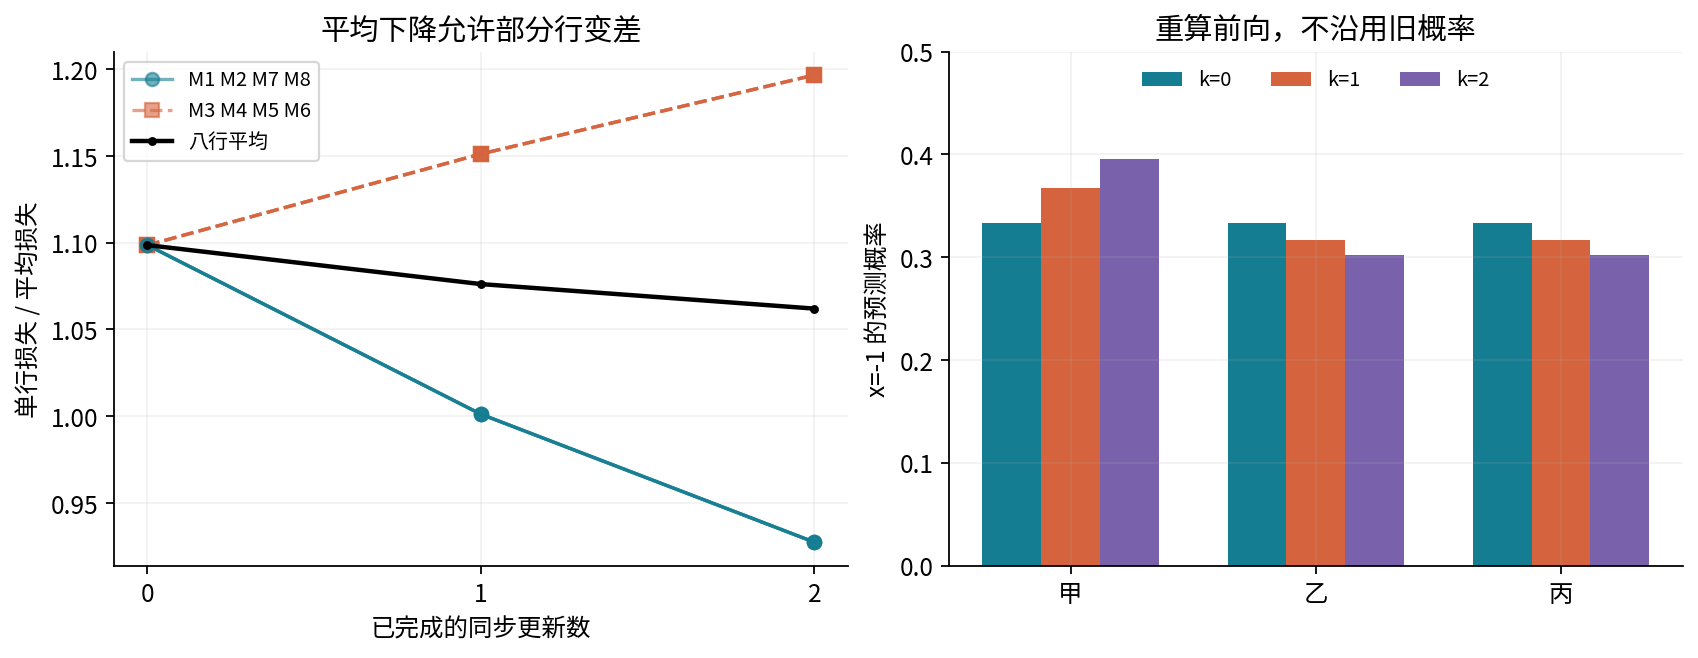

In [5]:
# All 24 full row chains, including local matrices, not just the final loss.
for k, state in enumerate(hand):
    print('\nSTATE', k, 'FULL EIGHT-ROW CHAIN')
    for sid, row in zip(ids, state['rows']):
        print(sid, json.dumps(row, ensure_ascii=False, sort_keys=True))
    summed = np.sum([row['gradient_contribution'] for row in state['rows']], axis=0)
    if not np.allclose(summed, state['gradient'], rtol=3e-13, atol=3e-14):
        raise RuntimeError('Rows did not sum to total gradient')
    print('Row-summed gradient:', summed)
show(4)

Initial softmax Jacobian: [[ 0.22222222 -0.11111111 -0.11111111]
 [-0.11111111  0.22222222 -0.11111111]
 [-0.11111111 -0.11111111  0.22222222]]
J @ ones: [0. 0. 0.]
Eigenvalues: [1.38777878e-17 3.33333333e-01 3.33333333e-01]
Common-column shift changes coefficients but not probabilities:
Max probability difference: 0.0


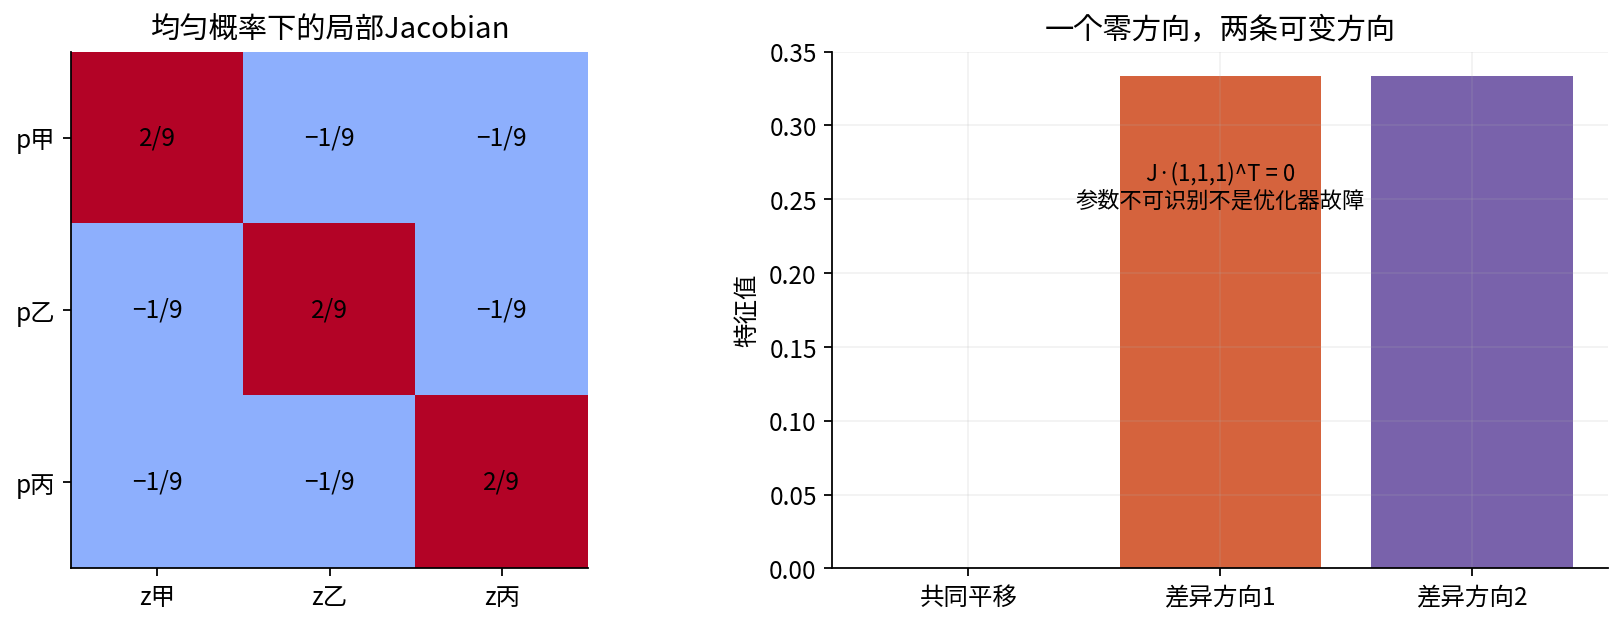

In [6]:
J = np.array(hand[0]['rows'][0]['local_softmax_jacobian'])
print('Initial softmax Jacobian:', J)
print('J @ ones:', J @ np.ones(3))
print('Eigenvalues:', np.linalg.eigvalsh(J))
print('Common-column shift changes coefficients but not probabilities:')
shifted_theta = np.array(hand[2]['theta']) + np.array([[.5], [-.25]])
shifted = e.row_ledger(X, y, shifted_theta)
print('Max probability difference:', np.max(np.abs(np.array(shifted['probabilities']) - hand[2]['probabilities'])))
show(5)

## 数值拟合与独立解析证书
注意BFGS的success=False会保留。训练正确率不是解析证书的替代。

Analytic certificate: {'theta': [[0.11552453009332421, -0.23104906018664842, 0.11552453009332421], [-0.34657359027997264, 0, 0.34657359027997264]], 'probabilities_at_minus_one': [0.5, 0.25, 0.25], 'probabilities_at_plus_one': [0.25, 0.25, 0.5], 'minimum_objective': 1.0397207708399179, 'scope': 'only eight declared rows; unique probabilities at x=-1,+1, sum-zero representative; common-column shifts remain unidentifiable'}
GD: gradient_tolerance 85 8.510451195701015e-11
GD final Theta: [[0.11552453004699913, -0.23104906009399837, 0.11552453004699918], [-0.3465735901409975, 3.3306690738754676e-17, 0.34657359014099753]]
Reference optimizer: {'name': 'SciPy BFGS, last class fixed at zero', 'success': False, 'message': 'Desired error not necessarily achieved due to precision loss.', 'iterations': 16, 'state': {'theta': [[0.11552453003709492, -0.23104906029333278, 0.11552453025623784], [-0.34657359033190765, -1.4798717806741024e-12, 0.34657359033338747]], 'objective': 1.039720770839918, 'grad

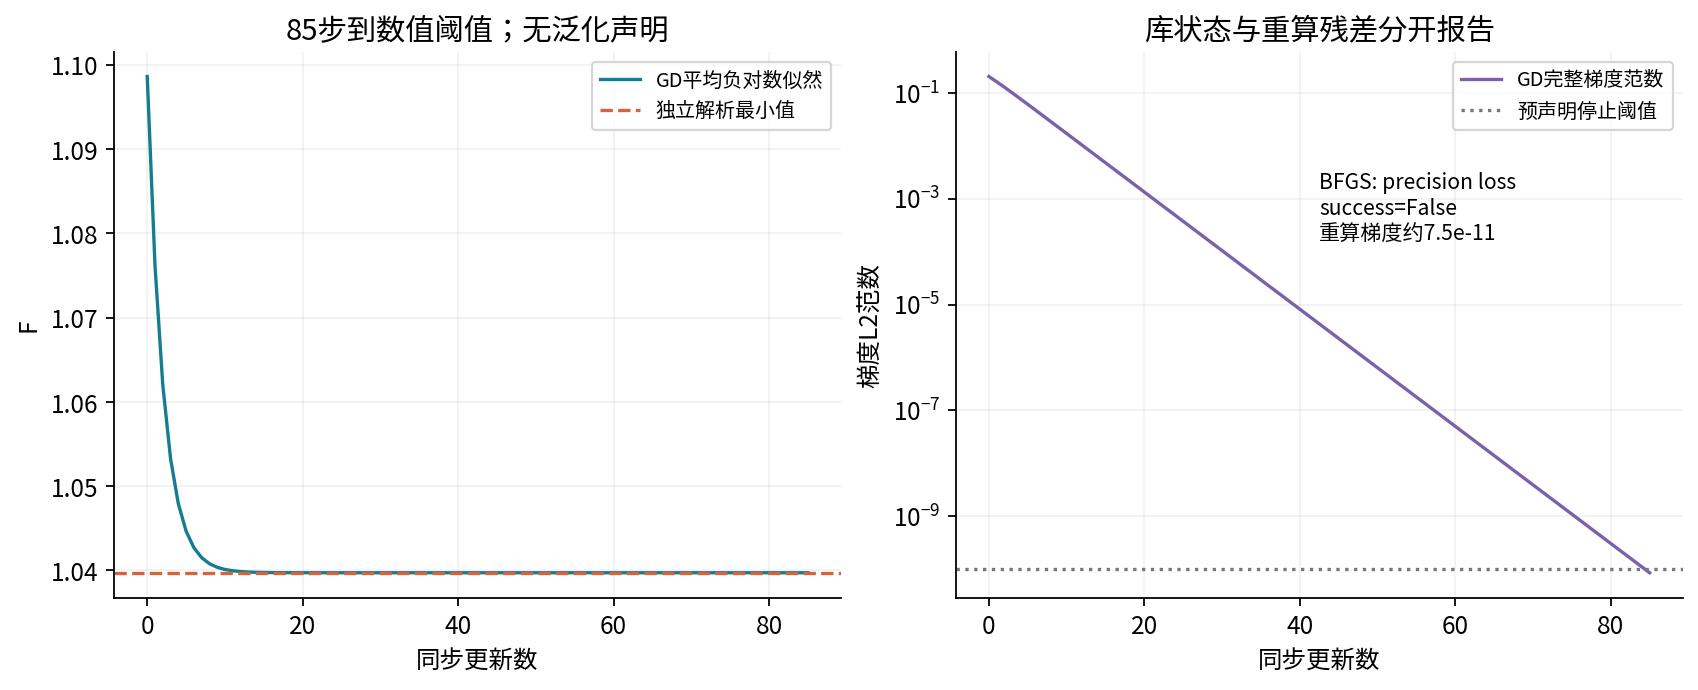

In [7]:
print('Analytic certificate:', report['certificate'])
print('GD:', report['fit']['status'], report['fit']['updates'], report['fit']['final']['gradient_norm'])
print('GD final Theta:', report['fit']['final']['theta'])
print('Reference optimizer:', report['reference_optimizer'])
print('Predictions:', report['training_predictions'], 'accuracy:', report['training_accuracy'])
show(6)

## 信息论分解与零支持
手算每一项，再比较两个方向；null加infinite标记代表正无穷，不代表缺失观测。

q to p: {'q': [0.5, 0.3, 0.2], 'p': [0.7, 0.2, 0.1], 'entropy': 1.0296530140645737, 'cross_entropy': 1.1216858642984053, 'kl': 0.09203285023383187, 'infinite_cross_entropy_and_kl': False, 'log_base': 'e'}
p to q: {'q': [0.7, 0.2, 0.1], 'p': [0.5, 0.3, 0.2], 'entropy': 0.8018185525433373, 'cross_entropy': 0.886941378500559, 'kl': 0.0851228259572216, 'infinite_cross_entropy_and_kl': False, 'log_base': 'e'}
Missing model support: {'q': [1.0, 0.0, 0.0], 'p': [0.0, 0.5, 0.5], 'entropy': -0.0, 'cross_entropy': None, 'kl': None, 'infinite_cross_entropy_and_kl': True, 'log_base': 'e'}
Identical deterministic distributions: {'q': [1.0, 0.0, 0.0], 'p': [1.0, 0.0, 0.0], 'entropy': -0.0, 'cross_entropy': -0.0, 'kl': 0.0, 'infinite_cross_entropy_and_kl': False, 'log_base': 'e'}


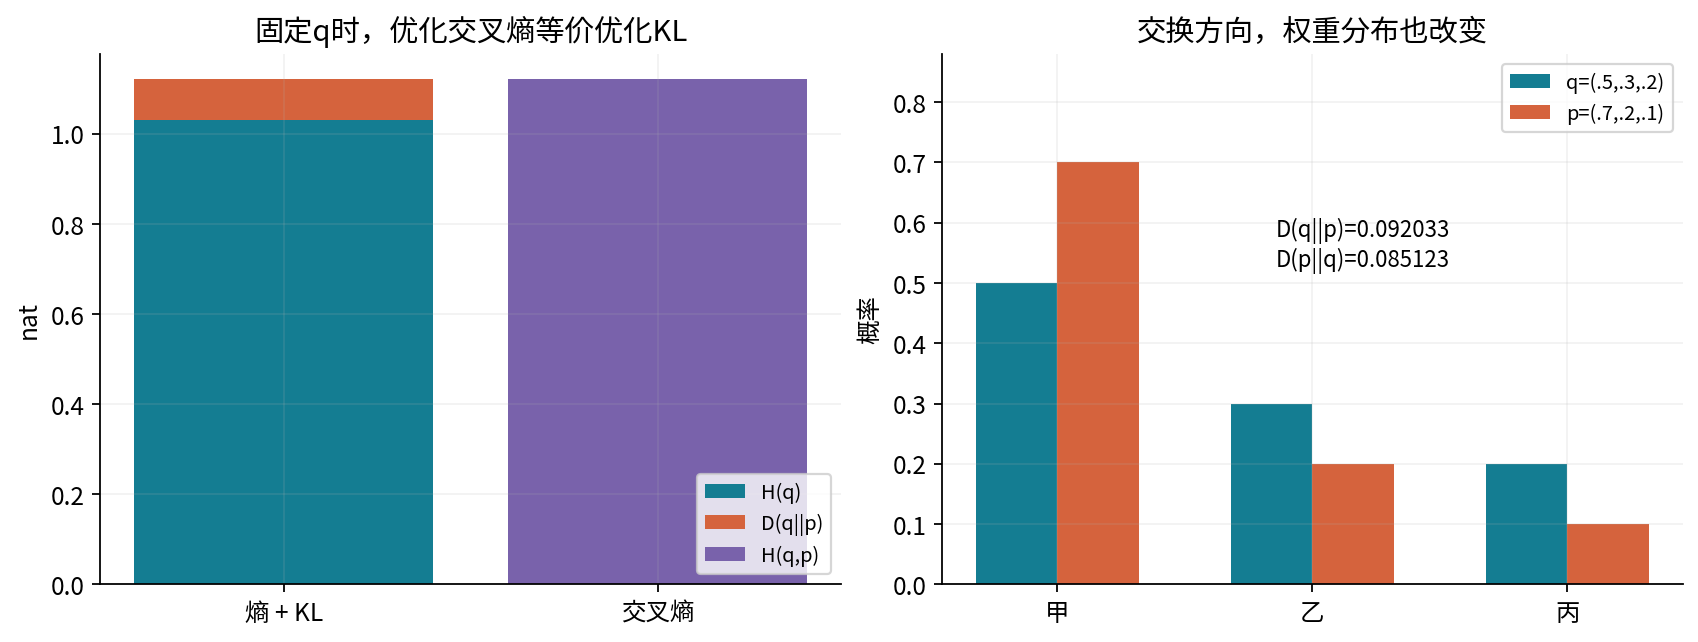

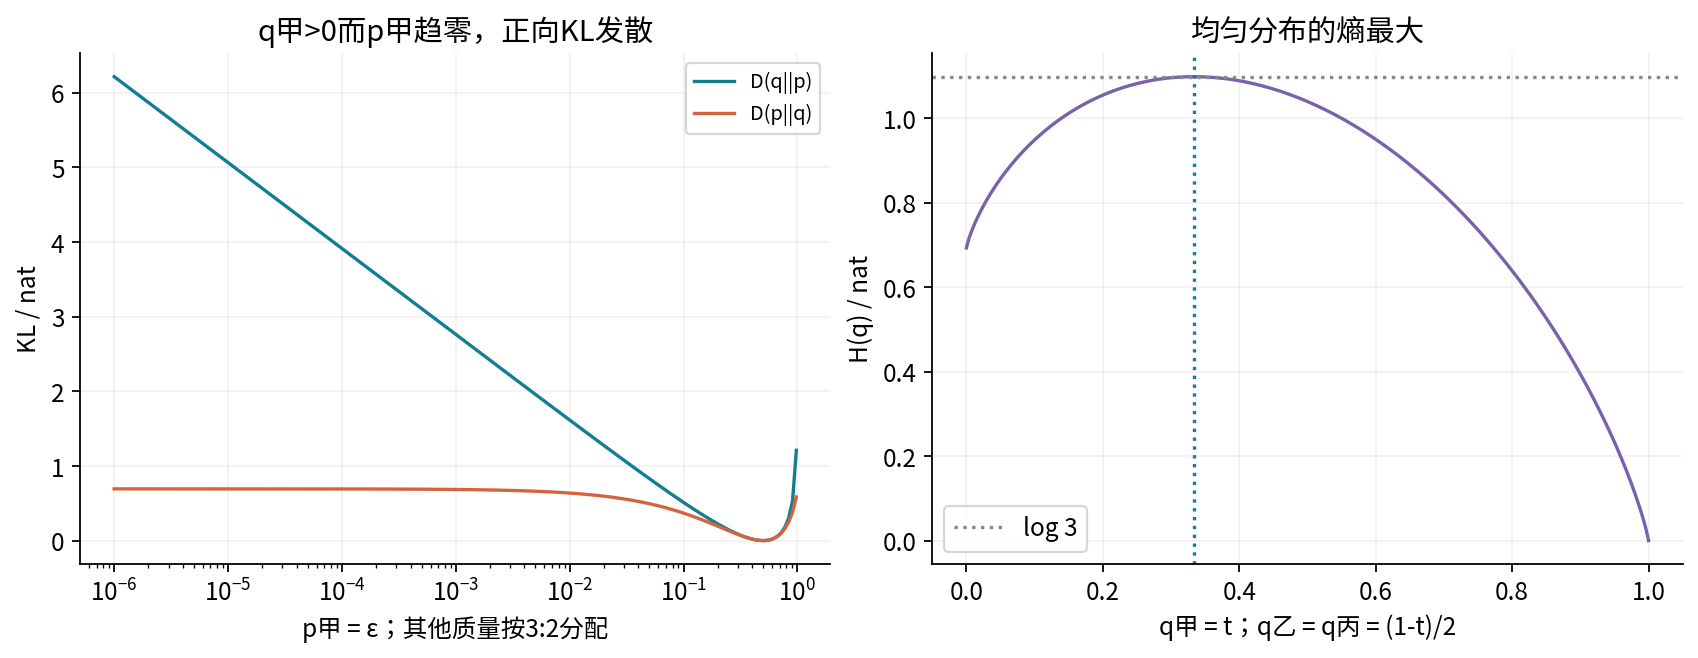

In [8]:
print('q to p:', report['information'])
print('p to q:', report['reverse_information'])
print('Missing model support:', report['support_failure'])
print('Identical deterministic distributions:', e.information([1, 0, 0], [1, 0, 0]))
show(7)
show(8)

## 数值失败要成为可解释证据
普通log(sum(exp))在赢者尾项上可能过早得到0；概率下溢与log概率有限可以同时成立。

{'logits': [0.0, -40.0, -40.0], 'probabilities': [1.0, 4.248354255291589e-18, 4.248354255291589e-18], 'log_probabilities': [-8.496708510583178e-18, -40.0, -40.0], 'scipy_probabilities': [1.0, 4.248354255291589e-18, 4.248354255291589e-18], 'scipy_log_probabilities': [0.0, -40.0, -40.0]}
{'logits': [1000.0, 0.0, -1000.0], 'probabilities': [1.0, 0.0, 0.0], 'log_probabilities': [0.0, -1000.0, -2000.0], 'scipy_probabilities': [1.0, 0.0, 0.0], 'scipy_log_probabilities': [0.0, -1000.0, -2000.0]}
{'logits': [-1000.0, -1000.0, -1000.0], 'probabilities': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333], 'log_probabilities': [-1.0986122886681098, -1.0986122886681098, -1.0986122886681098], 'scipy_probabilities': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333], 'scipy_log_probabilities': [-1.0986122886681098, -1.0986122886681098, -1.0986122886681098]}
Naive exponentials (intentional failure): [inf  1.  0.]
Naive normalization: [nan  0.  0.]
log(probabilities): [[  0. -inf -

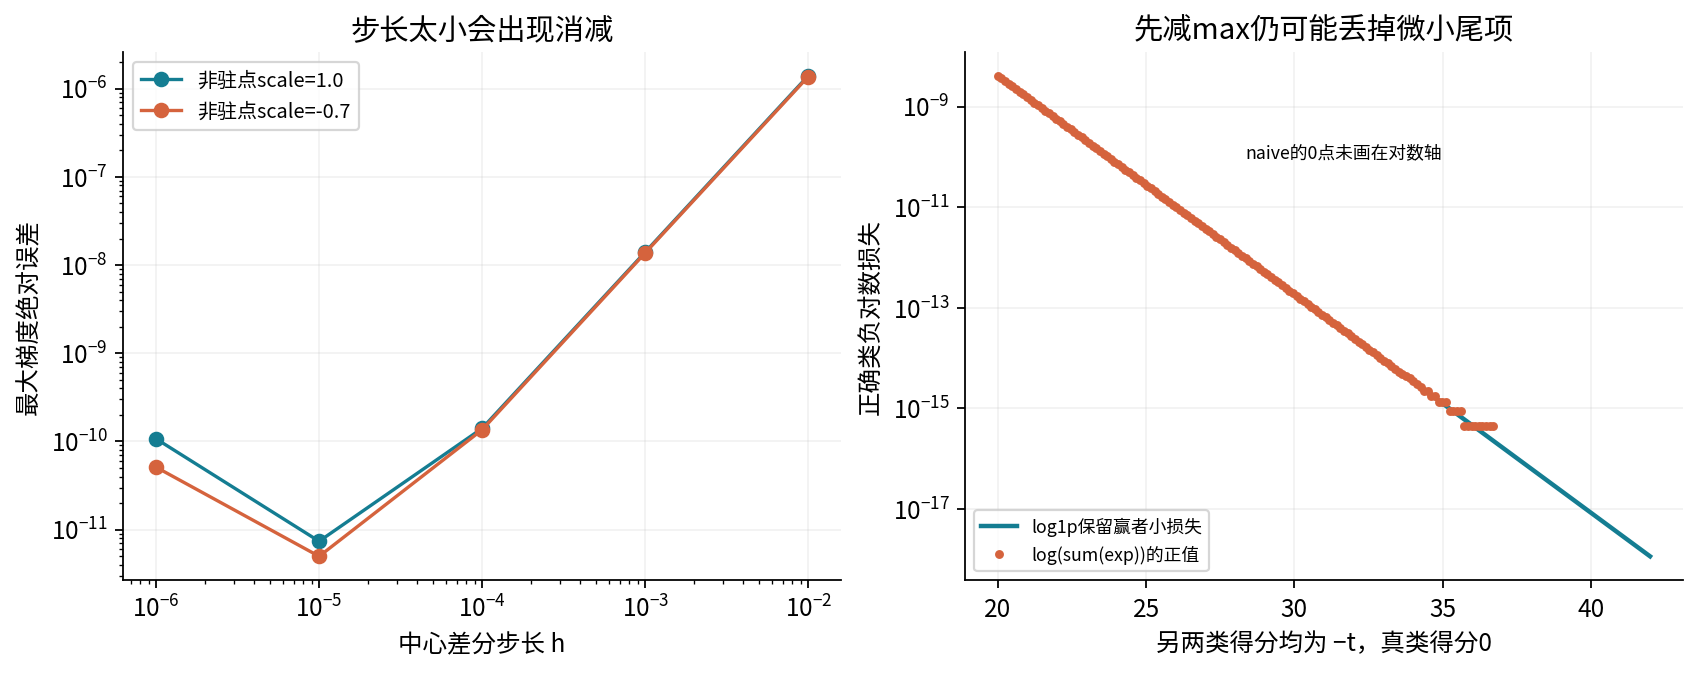

In [9]:
for row in report['diagnostics']['extremes']:
    print(row)
with np.errstate(over='ignore', invalid='ignore', divide='ignore'):
    bad = np.exp(np.array([1000., 0., -1000.]))
    print('Naive exponentials (intentional failure):', bad)
    print('Naive normalization:', bad / bad.sum())
p, logp = e.stable_softmax([[1000., 0., -1000.]])
with np.errstate(divide='ignore'):
    print('log(probabilities):', np.log(p))
print('Direct log probabilities:', logp)
print('Double-softmax:', e.stable_softmax([[.8, .1, .1]])[0])
for row in report['diagnostics']['finite_difference']:
    print(row)
show(9)

In [10]:
for label, kwargs in [('zero budget', {'max_updates': 0}),
                      ('short budget', {'max_updates': 1}),
                      ('initial stationary', {'initial': report['certificate']['theta']}),
                      ('rejected step', {'learning_rate': 100})]:
    args = {'initial': cfg['initial_theta'], **kwargs}
    result = e.fit(X, y, **args)
    print(label, result['status'], 'updates', result['updates'],
          'attempts', result['state_attempts'], 'successes', result['state_successes'])
    print('Second state:', result['trace'][2]['theta'] if len(result['trace']) > 2 else None)
try:
    bad_X = X.tolist(); bad_X[-1][-1] = True
    e.fit(bad_X, y, cfg['initial_theta'])
except ValueError as exc:
    print('Bad last field rejected:', str(exc))
else:
    raise RuntimeError('Invalid bool accepted')

zero budget max_updates updates 0 attempts 1 successes 1
Second state: None
short budget max_updates updates 1 attempts 2 successes 2
Second state: None
initial stationary gradient_tolerance updates 0 attempts 1 successes 1
Second state: None
rejected step step_rejected updates 0 attempts 2 successes 2
Second state: None
Bad last field rejected: X must be a real numeric scalar, not bool/string/complex


In [11]:
import audit
verified = audit.audit()
print('Independent exact and Decimal checks:', verified)
core = hashlib.sha256(e.canonical_bytes(report)).hexdigest()
if core != verified['core_sha256']:
    raise RuntimeError('Whole Notebook scientific result differs from audit')
e.safe_write(BASE / 'outputs/notebook-result.json', report)
print('Complete scientific SHA256:', core)
print('Limitations:', report['limitations'])

Independent exact and Decimal checks: {'unit': '043', 'science': {'exact_initial_gradient': [['-1/24', '1/12', '-1/24'], ['1/8', '0', '-1/8']], 'Decimal_checked_full_states': 86, 'Decimal_precision': 100, 'tail_precision': 1000, 'non_square_shapes': [(1, 1, 2), (4, 3, 5), (7, 2, 3), (2, 5, 2), (9, 1, 7)], 'reference_optimizer_success': False, 'reference_optimizer_message': 'Desired error not necessarily achieved due to precision loss.', 'reference_recomputed_gradient': 7.521933084315595e-11}, 'guards': {'invalid_numeric_tail_cases': 24, 'zero_short_stationary_rejected_states_checked': True, 'config_all_fields_checked': True, 'failure_cost_checked': True, 'atomic_output_preservation': True}, 'core_sha256': '87e056534607741fbaac07f3fdcd535baa94db70b26790a8355466b181f4d34b'}
Complete scientific SHA256: 87e056534607741fbaac07f3fdcd535baa94db70b26790a8355466b181f4d34b
Limitations: ['synthetic mechanism data, no generalization or calibration claim', 'float64 supported finite input ranges, re

## 完成练习
按answers.pdf核对十八题；尤其要解释同一x的冲突标签、有限最优点、KL支持集及保留的不成功状态。运行成功不是现实部署或研究新颖性的证据。